In [2]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


file_path = "../data/supermarket_sales - Sheet1.csv"
df = pd.read_csv(file_path, encoding="Unicode_escape")


print(f"Dataset Ölçüsü: {df.shape}")
print(f"Sütun Adları: {df.columns.tolist()}")

Dataset Ölçüsü: (1000, 17)
Sütun Adları: ['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']


In [3]:
display(df.head())

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [7]:
df['Date'] = pd.to_datetime(df['Date']) 
df['Time'] = pd.to_datetime(df['Time'],format='%H:%M').dt.time

print(df[['Date', 'Time']].dtypes)
print(df[['Date', 'Time']].head())

Date    datetime64[us]
Time            object
dtype: object
        Date      Time
0 2019-01-05  13:08:00
1 2019-03-08  10:29:00
2 2019-03-03  13:23:00
3 2019-01-27  20:33:00
4 2019-02-08  10:37:00


In [10]:
branch_analysis= df.groupby('Branch').agg(
    total_sales=('Total','sum'),
    order_count=('Invoice ID','count')
).reset_index()

print(branch_analysis)

  Branch  total_sales  order_count
0      A  106200.3705          340
1      B  106197.6720          332
2      C  110568.7065          328


In [13]:
product_analysis= df.groupby('Product line').agg(
    total_sales=('Total','sum'),
    order_count=('Invoice ID','count')
).reset_index().sort_values(by='total_sales', ascending=False)

print(product_analysis)

             Product line  total_sales  order_count
2      Food and beverages   56144.8440          174
5       Sports and travel   55122.8265          166
0  Electronic accessories   54337.5315          170
1     Fashion accessories   54305.8950          178
4      Home and lifestyle   53861.9130          160
3       Health and beauty   49193.7390          152


In [14]:
customer_analysis= df.groupby('Customer type').agg(
    total_sales=('Total','sum'),
    order_count=('Invoice ID','count')
).reset_index()

print(customer_analysis)

  Customer type  total_sales  order_count
0        Member   164223.444          501
1        Normal   158743.305          499


In [15]:
gender_analysis= df.groupby('Gender').agg(
    total_sales=('Total','sum'),
    order_count=('Invoice ID','count')
).reset_index()

print(gender_analysis)

   Gender  total_sales  order_count
0  Female   167882.925          501
1    Male   155083.824          499


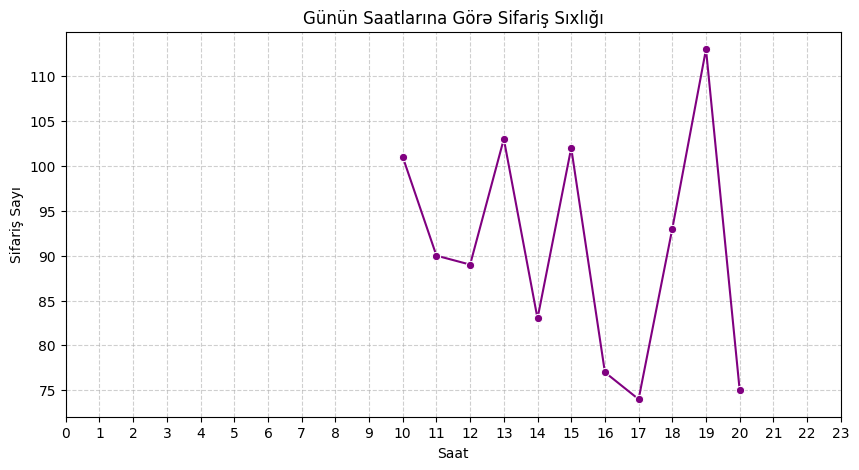

In [17]:
df['Hour'] = df['Time'].apply(lambda x: x.hour)
hourly_activity = df.groupby('Hour').agg(
    Order_Count=('Invoice ID', 'count')
).reset_index()

busiest_hour = hourly_activity.sort_values(by='Order_Count', ascending=False).iloc[0]

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_activity, x='Hour', y='Order_Count', marker='o', color='purple')
plt.title('Günün Saatlarına Görə Sifariş Sıxlığı')
plt.xlabel('Saat')
plt.ylabel('Sifariş Sayı')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [27]:
revenue= df.groupby('Product line').agg(
    total_revenue=('Total','sum'),
).reset_index().sort_values(by='total_revenue', ascending=False)

top =revenue.iloc[0]
bottom =revenue.iloc[-1]

print(revenue.to_string(index=False))
print(f" Ən çox gəlir gətirən : {top['Product line']} (${top['total_revenue']:.2f})")
print(f" Ən az gəlir gətirən : {bottom['Product line']} (${bottom['total_revenue']:.2f})")





          Product line  total_revenue
    Food and beverages     56144.8440
     Sports and travel     55122.8265
Electronic accessories     54337.5315
   Fashion accessories     54305.8950
    Home and lifestyle     53861.9130
     Health and beauty     49193.7390
 Ən çox gəlir gətirən : Food and beverages ($56144.84)
 Ən az gəlir gətirən : Health and beauty ($49193.74)


C:\Users\Amin Rzazade\AppData\Local\Temp\ipykernel_36808\4277015557.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


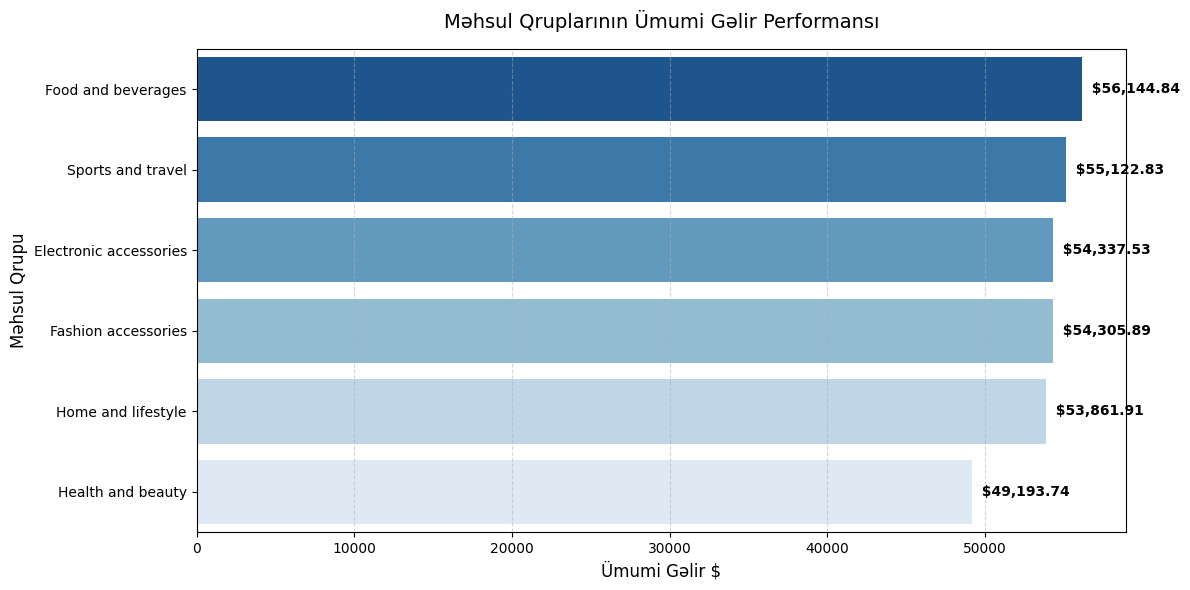

In [30]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=revenue, 
    x='total_revenue', 
    y='Product line', 
    palette='Blues_r'  
)

plt.title('Məhsul Qruplarının Ümumi Gəlir Performansı', fontsize=14, pad=15)
plt.xlabel('Ümumi Gəlir $', fontsize=12)
plt.ylabel('Məhsul Qrupu', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)


for index, value in enumerate(revenue['total_revenue']):
    plt.text(value, index, f'  ${value:,.2f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

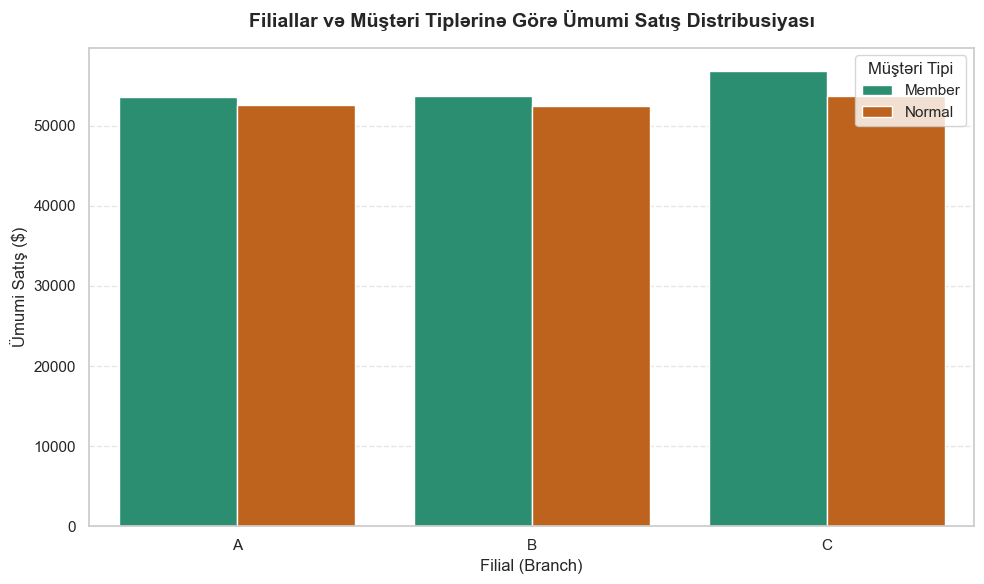

In [34]:
branch_cust = df.groupby(['Branch', 'Customer type']).agg(Total_Sales=('Total', 'sum')).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=branch_cust, 
    x='Branch', 
    y='Total_Sales', 
    hue='Customer type', 
    palette='Dark2'
)

plt.title('Filiallar və Müştəri Tiplərinə Görə Ümumi Satış Distribusiyası', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Filial (Branch)', fontsize=12)
plt.ylabel('Ümumi Satış ($)', fontsize=12)
plt.legend(title='Müştəri Tipi')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [3]:
margin_analysis = df.groupby('Product line').agg(
    Total_Revenue=('Total', 'sum'),
    Total_Gross_Income=('gross income', 'sum')
).reset_index()

margin_analysis['Gross Margin %'] = (margin_analysis['Total_Gross_Income'] / margin_analysis['Total_Revenue']) * 100
print(margin_analysis[['Product line', 'Gross Margin %']])

             Product line  Gross Margin %
0  Electronic accessories        4.761905
1     Fashion accessories        4.761905
2      Food and beverages        4.761905
3       Health and beauty        4.761905
4      Home and lifestyle        4.761905
5       Sports and travel        4.761905


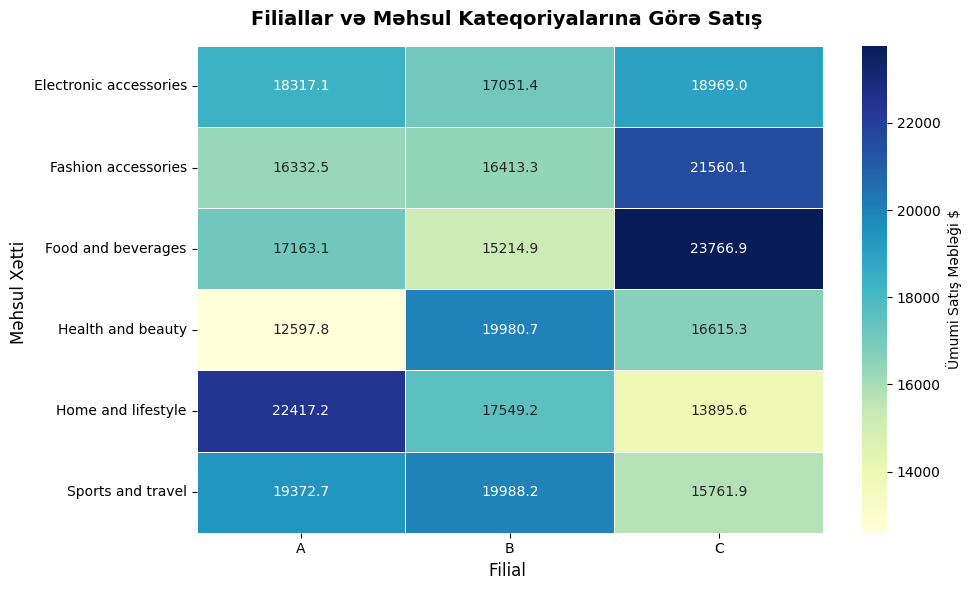

In [5]:
data = df.pivot_table(
    index='Product line', 
    columns='Branch', 
    values='Total', 
    aggfunc='sum'
)


plt.figure(figsize=(10, 6))
sns.heatmap(
   
     data, 
    annot=True,          
    fmt=".1f",          
    cmap="YlGnBu",       
    linewidths=0.5,      
    cbar_kws={'label': 'Ümumi Satış Məbləği $'}
)

plt.title('Filiallar və Məhsul Kateqoriyalarına Görə Satış ', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Filial ', fontsize=12)
plt.ylabel('Məhsul Xətti ', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()